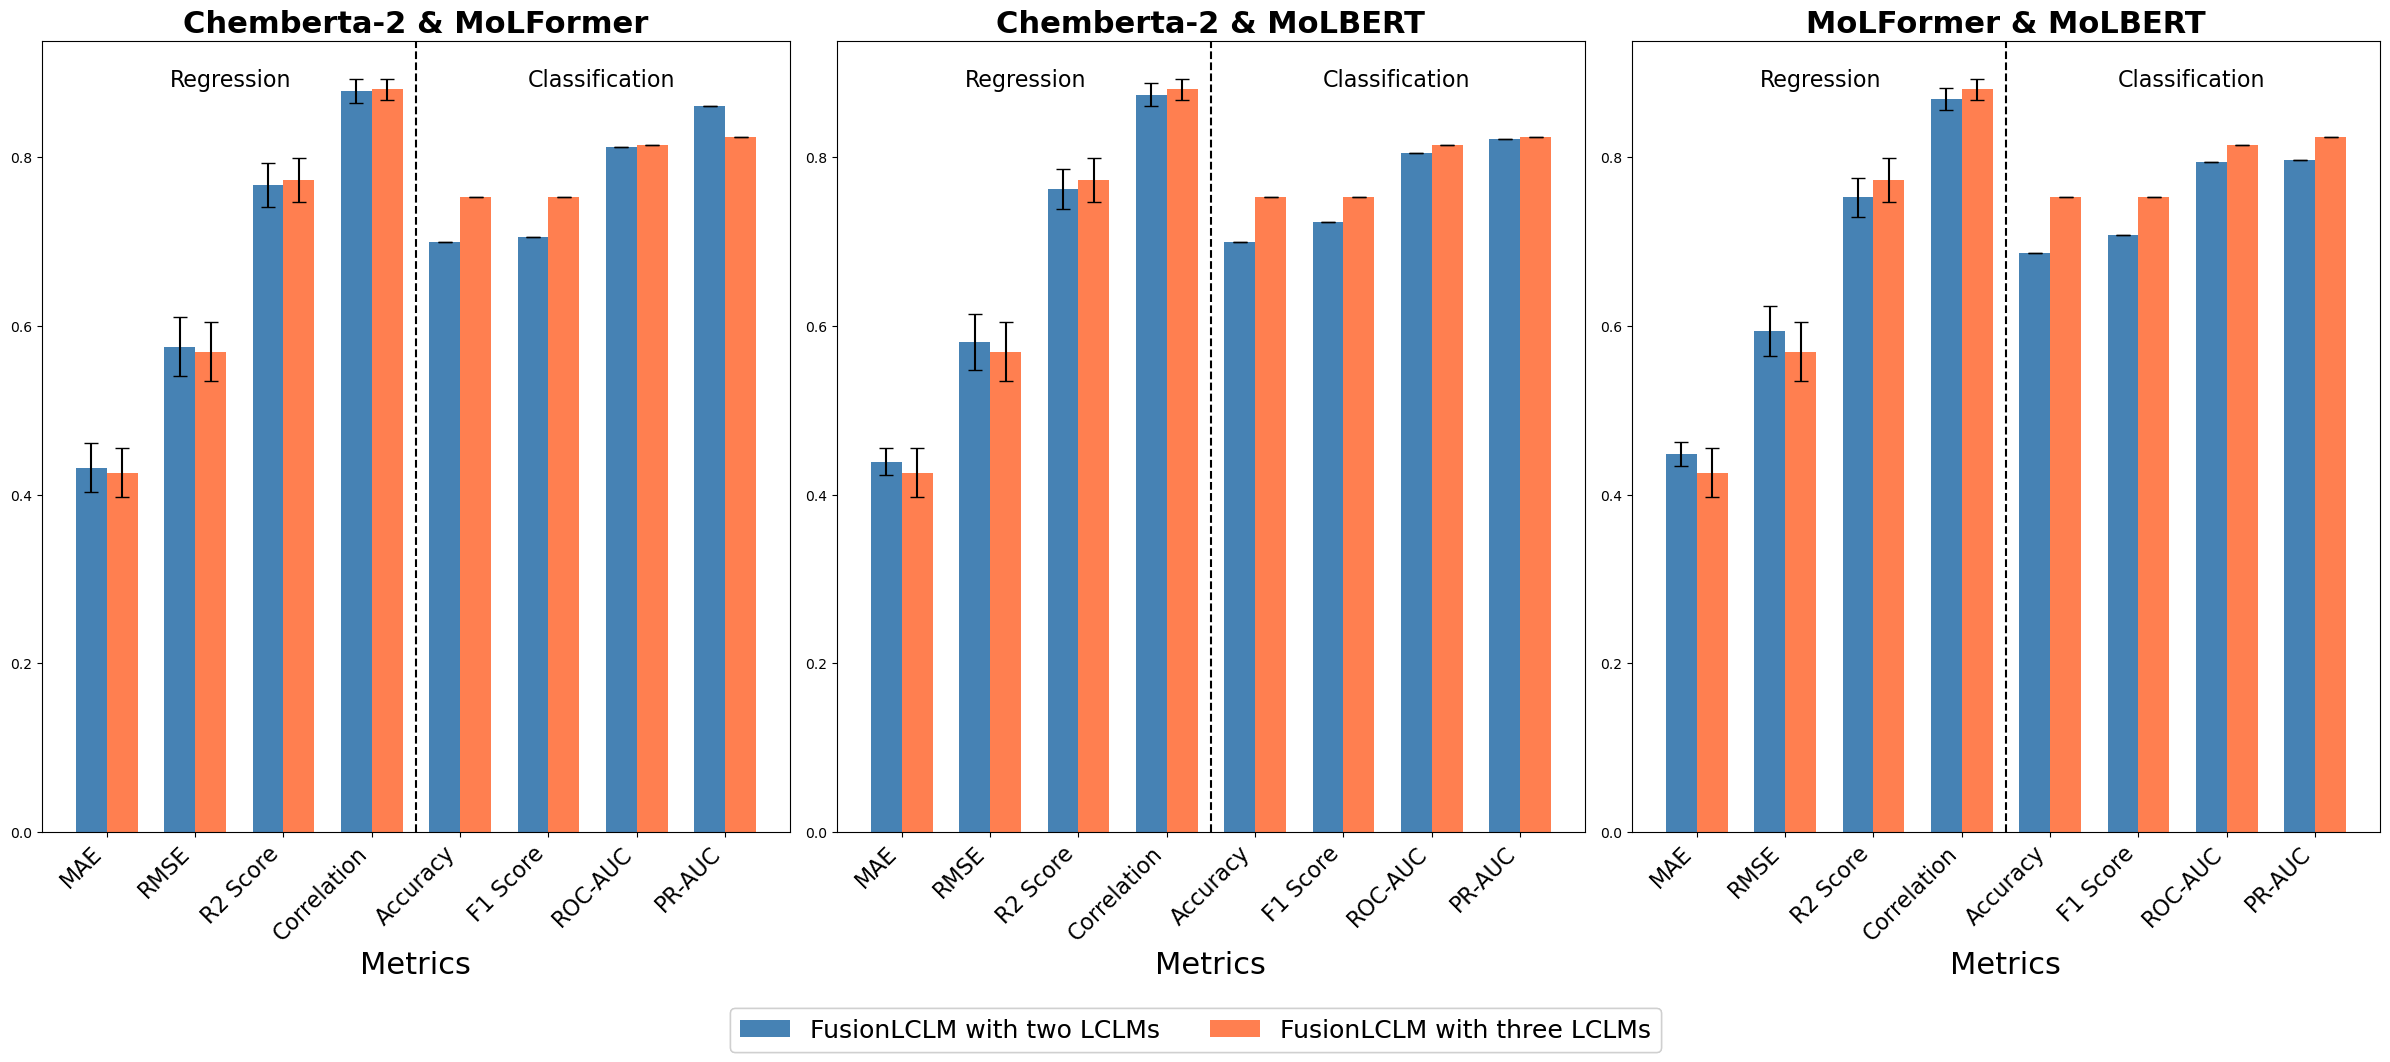

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Data with standard deviation for LASSO
lasso_data = {
    "Chemberta-2 & MoLFormer": {
        "Regression": {
            "MAE": 0.432,
            "MAE_STD": 0.029,
            "RMSE": 0.575,
            "RMSE_STD": 0.035,
            "R2 Score": 0.767,
            "R2 Score_STD": 0.026,
            "Correlation": 0.878,
            "Correlation_STD": 0.014
        },
        "Classification": {
            "Accuracy": 0.699,
            "Accuracy_STD": 0.000,
            "F1 Score": 0.705,
            "F1 Score_STD": 0.000,
            "ROC-AUC": 0.812,
            "ROC-AUC_STD": 0.000,
            "PR-AUC": 0.861,
            "PR-AUC_STD": 0.000
        }
    },
    "Chemberta-2 & MoLBERT": {
        "Regression": {
            "MAE": 0.439,
            "MAE_STD": 0.016,
            "RMSE": 0.581,
            "RMSE_STD": 0.033,
            "R2 Score": 0.762,
            "R2 Score_STD": 0.024,
            "Correlation": 0.874,
            "Correlation_STD": 0.014
        },
        "Classification": {
            "Accuracy": 0.699,
            "Accuracy_STD": 0.000,
            "F1 Score": 0.723,
            "F1 Score_STD": 0.000,
            "ROC-AUC": 0.805,
            "ROC-AUC_STD": 0.000,
            "PR-AUC": 0.821,
            "PR-AUC_STD": 0.000
        }
    },
    "MoLFormer & MoLBERT": {
        "Regression": {
            "MAE": 0.448,
            "MAE_STD": 0.014,
            "RMSE": 0.594,
            "RMSE_STD": 0.030,
            "R2 Score": 0.752,
            "R2 Score_STD": 0.023,
            "Correlation": 0.869,
            "Correlation_STD": 0.013
        },
        "Classification": {
            "Accuracy": 0.686,
            "Accuracy_STD": 0.000,
            "F1 Score": 0.707,
            "F1 Score_STD": 0.000,
            "ROC-AUC": 0.794,
            "ROC-AUC_STD": 0.000,
            "PR-AUC": 0.797,
            "PR-AUC_STD": 0.000
        }
    }
}

three_model_data = {
    "Regression": {
        "MAE": 0.426,
        "MAE_STD": 0.029,
        "RMSE": 0.569,
        "RMSE_STD": 0.035,
        "R2 Score": 0.773,
        "R2 Score_STD": 0.026,
        "Correlation": 0.880,
        "Correlation_STD": 0.013
    },
    "Classification": {
        "Accuracy": 0.752,
        "Accuracy_STD": 0.000,
        "F1 Score": 0.752,
        "F1 Score_STD": 0.000,
        "ROC-AUC": 0.814,
        "ROC-AUC_STD": 0.000,
        "PR-AUC": 0.824,
        "PR-AUC_STD": 0.000
    }
}

def plot_metrics(ax, title, metrics, three_model_metrics, colors):
    labels = ["MAE", "RMSE", "R2 Score", "Correlation", "Accuracy", "F1 Score", "ROC-AUC", "PR-AUC"]
    
    two_model_values = [metrics[title]["Regression"]["MAE"], metrics[title]["Regression"]["RMSE"], 
                        metrics[title]["Regression"]["R2 Score"], metrics[title]["Regression"]["Correlation"], 
                        metrics[title]["Classification"]["Accuracy"], metrics[title]["Classification"]["F1 Score"], 
                        metrics[title]["Classification"]["ROC-AUC"], metrics[title]["Classification"]["PR-AUC"]]
    two_model_stds = [metrics[title]["Regression"]["MAE_STD"], metrics[title]["Regression"]["RMSE_STD"], 
                      metrics[title]["Regression"]["R2 Score_STD"], metrics[title]["Regression"]["Correlation_STD"], 
                      metrics[title]["Classification"]["Accuracy_STD"], metrics[title]["Classification"]["F1 Score_STD"], 
                      metrics[title]["Classification"]["ROC-AUC_STD"], metrics[title]["Classification"]["PR-AUC_STD"]]

    three_model_values = [three_model_metrics["Regression"]["MAE"], three_model_metrics["Regression"]["RMSE"], 
                          three_model_metrics["Regression"]["R2 Score"], three_model_metrics["Regression"]["Correlation"], 
                          three_model_metrics["Classification"]["Accuracy"], three_model_metrics["Classification"]["F1 Score"], 
                          three_model_metrics["Classification"]["ROC-AUC"], three_model_metrics["Classification"]["PR-AUC"]]
    three_model_stds = [three_model_metrics["Regression"]["MAE_STD"], three_model_metrics["Regression"]["RMSE_STD"], 
                        three_model_metrics["Regression"]["R2 Score_STD"], three_model_metrics["Regression"]["Correlation_STD"], 
                        three_model_metrics["Classification"]["Accuracy_STD"], three_model_metrics["Classification"]["F1 Score_STD"], 
                        three_model_metrics["Classification"]["ROC-AUC_STD"], three_model_metrics["Classification"]["PR-AUC_STD"]]
    
    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, two_model_values, width, yerr=two_model_stds, label='FusionLCLM with two LCLMs', color=colors[0], capsize=5)
    ax.bar(x + width/2, three_model_values, width, yerr=three_model_stds, label='FusionLCLM with three LCLMs', color=colors[1], capsize=5)
    
    ax.set_xlabel('Metrics', fontsize=22)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, fontsize=16, ha="right")
    ax.axvline(x=3.5, color='black', linestyle='--')
    ax.text(1.4, 0.95, 'Regression', fontsize=16, color='black', ha='center', va='center', transform=ax.get_xaxis_transform())
    ax.text(5.6, 0.95, 'Classification', fontsize=16, color='black', ha='center', va='center', transform=ax.get_xaxis_transform())
    # Add a single legend at the bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.001), ncol=2, fontsize=18)


fig, axes = plt.subplots(1, 3, figsize=(24, 10))
colors = ['#4682B4','#FF7F50'] 

for i, model_comb in enumerate(lasso_data.keys()):
    plot_metrics(axes[i], model_comb, lasso_data, three_model_data, colors)

plt.tight_layout()
plt.show()


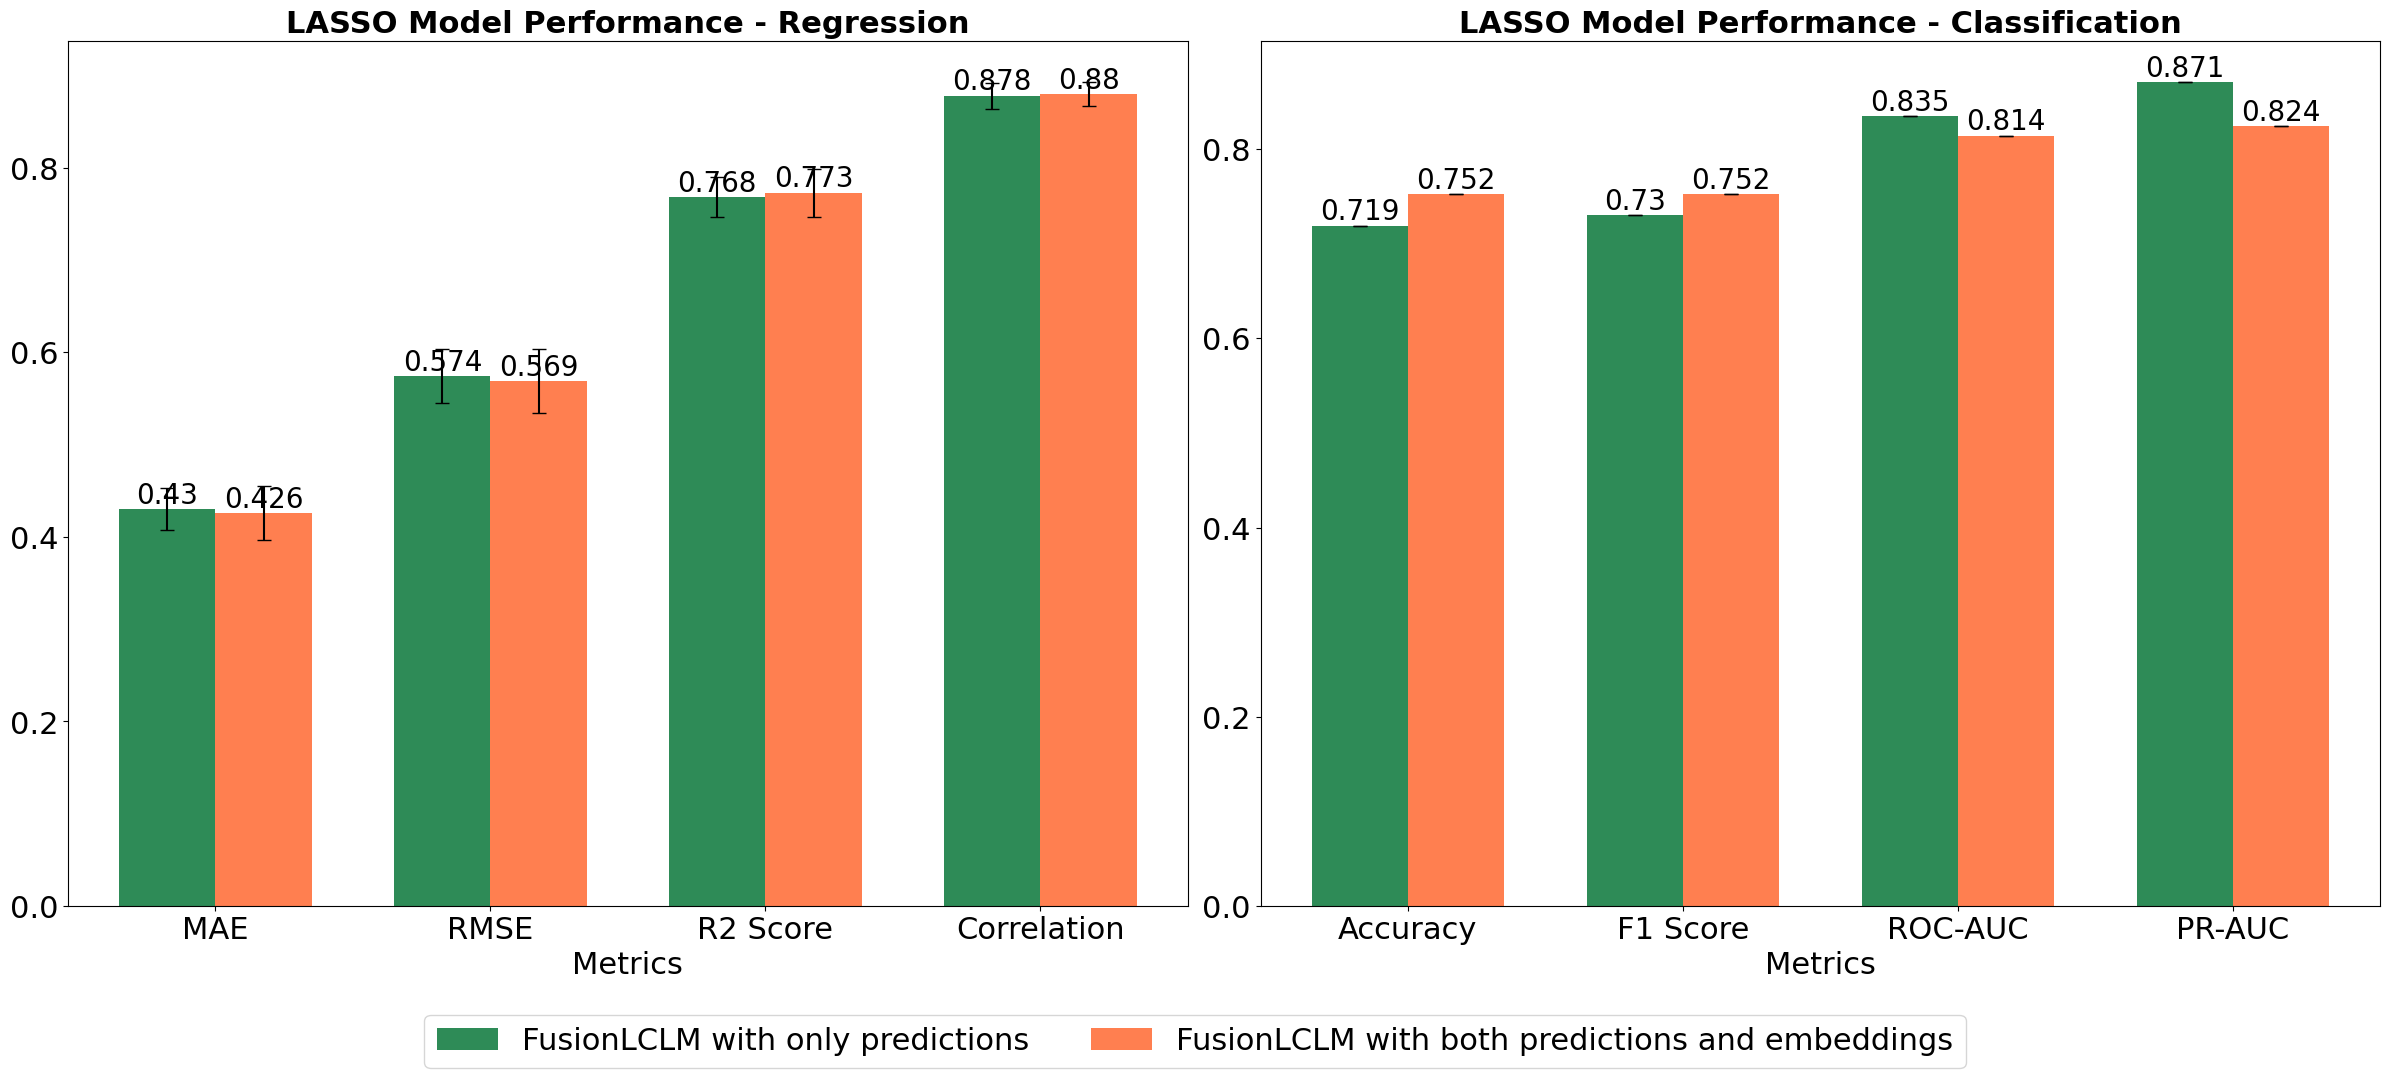

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Original three-model analysis
three_model_data = {
    "Regression": {
        "MAE": 0.426,
        "MAE_STD": 0.029,
        "RMSE": 0.569,
        "RMSE_STD": 0.035,
        "R2 Score": 0.773,
        "R2 Score_STD": 0.026,
        "Correlation": 0.880,
        "Correlation_STD": 0.013
    },
    "Classification": {
        "Accuracy": 0.752,
        "Accuracy_STD": 0.000,
        "F1 Score": 0.752,
        "F1 Score_STD": 0.000,
        "ROC-AUC": 0.814,
        "ROC-AUC_STD": 0.000,
        "PR-AUC": 0.824,
        "PR-AUC_STD": 0.000
    }
}

# Alternative analysis
alternative_data = {
    "Regression": {
        "MAE": 0.430,
        "MAE_STD": 0.023,
        "RMSE": 0.574,
        "RMSE_STD": 0.029,
        "R2 Score": 0.768,
        "R2 Score_STD": 0.022,
        "Correlation": 0.878,
        "Correlation_STD": 0.014
    },
    "Classification": {
        "Accuracy": 0.719,
        "Accuracy_STD": 0.000,
        "F1 Score": 0.730,
        "F1 Score_STD": 0.000,
        "ROC-AUC": 0.835,
        "ROC-AUC_STD": 0.000,
        "PR-AUC": 0.871,
        "PR-AUC_STD": 0.000
    }
}

def plot_metrics(ax, title, metrics, labels, colors):
    alternative_values = [metrics["Alternative"][label] for label in labels]
    alternative_stds = [metrics["Alternative"][label + "_STD"] for label in labels]

    original_values = [metrics["Original"][label] for label in labels]
    original_stds = [metrics["Original"][label + "_STD"] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, alternative_values, width, yerr=alternative_stds, label='FusionLCLM with only predictions', color=colors[0], capsize=5)
    bars2 = ax.bar(x + width/2, original_values, width, yerr=original_stds, label='FusionLCLM with both predictions and embeddings', color=colors[1], capsize=5)
    
    for bar in bars1:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom', fontsize=20)
        
    for bar in bars2:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom', fontsize=20)

    ax.set_xlabel('Metrics', fontsize=22)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=22)
    ax.tick_params(axis='y', labelsize=22)

# Prepare data for plotting
regression_labels = ["MAE", "RMSE", "R2 Score", "Correlation"]
classification_labels = ["Accuracy", "F1 Score", "ROC-AUC", "PR-AUC"]

regression_data = {
    "Original": three_model_data["Regression"],
    "Alternative": alternative_data["Regression"]
}

classification_data = {
    "Original": three_model_data["Classification"],
    "Alternative": alternative_data["Classification"]
}

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
colors = ['#2E8B57', '#FF7F50']  # Medium Teal for alternative analysis, Medium Coral for original analysis

plot_metrics(axes[0], "LASSO Model Performance - Regression", regression_data, regression_labels, colors)
plot_metrics(axes[1], "LASSO Model Performance - Classification", classification_data, classification_labels, colors)

# Add a single legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.005), ncol=2, fontsize=22)

plt.tight_layout()
plt.show()


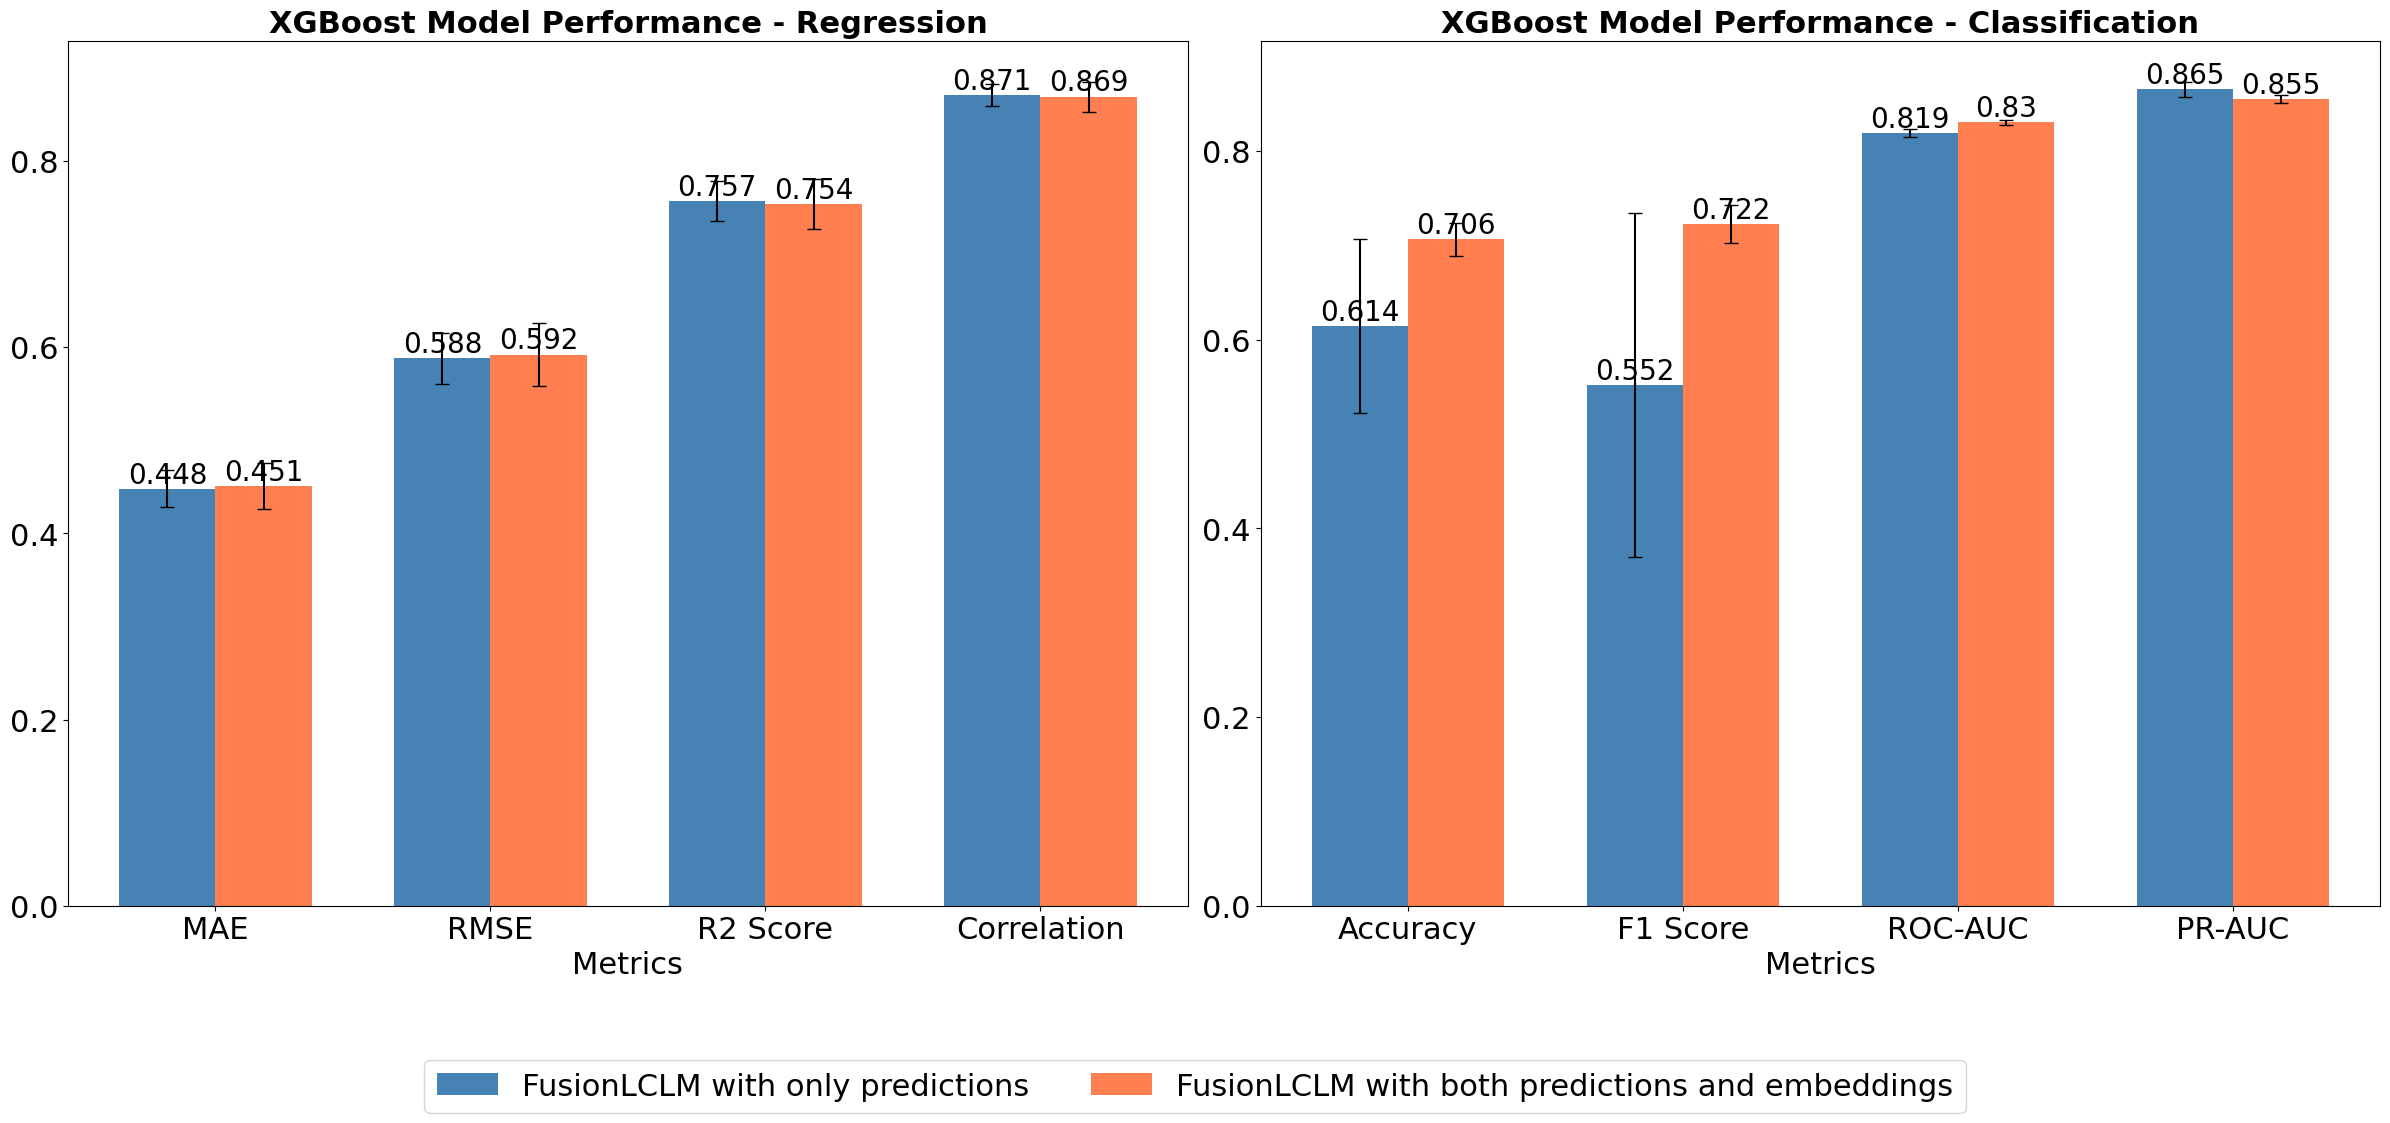

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Original analysis
original_data = {
    "Regression": {
        "MAE": 0.451,
        "MAE_STD": 0.025,
        "RMSE": 0.592,
        "RMSE_STD": 0.034,
        "R2 Score": 0.754,
        "R2 Score_STD": 0.027,
        "Correlation": 0.869,
        "Correlation_STD": 0.016
    },
    "Classification": {
        "Accuracy": 0.706,
        "Accuracy_STD": 0.017,
        "F1 Score": 0.722,
        "F1 Score_STD": 0.020,
        "ROC-AUC": 0.830,
        "ROC-AUC_STD": 0.003,
        "PR-AUC": 0.855,
        "PR-AUC_STD": 0.004
    }
}

# Alternative analysis
alternative_data = {
    "Regression": {
        "MAE": 0.448,
        "MAE_STD": 0.020,
        "RMSE": 0.588,
        "RMSE_STD": 0.027,
        "R2 Score": 0.757,
        "R2 Score_STD": 0.021,
        "Correlation": 0.871,
        "Correlation_STD": 0.012
    },
    "Classification": {
        "Accuracy": 0.614,
        "Accuracy_STD": 0.092,
        "F1 Score": 0.552,
        "F1 Score_STD": 0.182,
        "ROC-AUC": 0.819,
        "ROC-AUC_STD": 0.004,
        "PR-AUC": 0.865,
        "PR-AUC_STD": 0.008
    }
}

def plot_metrics(ax, title, metrics, labels, colors):
    alternative_values = [metrics["Alternative"][label] for label in labels]
    alternative_stds = [metrics["Alternative"][label + "_STD"] for label in labels]

    original_values = [metrics["Original"][label] for label in labels]
    original_stds = [metrics["Original"][label + "_STD"] for label in labels]
    
    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, alternative_values, width, yerr=alternative_stds, label='FusionLCLM with only predictions', color=colors[0], capsize=5)
    bars2 = ax.bar(x + width/2, original_values, width, yerr=original_stds, label='FusionLCLM with both predictions and embeddings', color=colors[1], capsize=5)
    
    for bar in bars1:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom', fontsize=20)
        
    for bar in bars2:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom', fontsize=20)

    ax.set_xlabel('Metrics', fontsize=22)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=22)
    ax.tick_params(axis='y', labelsize=22)

# Prepare data for plotting
regression_labels = ["MAE", "RMSE", "R2 Score", "Correlation"]
classification_labels = ["Accuracy", "F1 Score", "ROC-AUC", "PR-AUC"]

regression_data = {
    "Original": original_data["Regression"],
    "Alternative": alternative_data["Regression"]
}

classification_data = {
    "Original": original_data["Classification"],
    "Alternative": alternative_data["Classification"]
}

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
colors = ['#4682B4', '#FF7F50']  # Medium Teal for alternative analysis, Medium Coral for original analysis

plot_metrics(axes[0], "XGBoost Model Performance - Regression", regression_data, regression_labels, colors)
plot_metrics(axes[1], "XGBoost Model Performance - Classification", classification_data, classification_labels, colors)

# Add a single legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=22)

plt.tight_layout()
plt.show()
